In [599]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql.functions import col
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, regexp_replace, to_date, count, sum as spark_sum, isnan
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

In [600]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

# 3. Financials Dataset

In [ ]:
# # ===== PySpark version =====
financials_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/features_financials/bronze_financials_*.csv")
)
# financials_df.printSchema()
# print("Row count:", financials_df.count())
# financials_df.show(5, truncate=False)

# ===== Pandas mirror (easier to read) =====
financials_pdf = financials_df.toPandas()
financials_pdf.head()

In [ ]:
financials_pdf.info()

In [ ]:
financials_pdf.describe()

### Missing value: 
- ### Type_of_Loan null -> 1426 row

In [ ]:
# # ===== PySpark version =====
# financials_df.select([
#     spark_sum(col(c).isNull().cast("int")).alias(c)
#     for c in financials_df.columns
# ]).show()

# ===== Pandas mirror =====
print("\n--- Pandas null counts ---")
financials_pdf.isnull().sum()

In [ ]:
# ===== PySpark version =====
# Credit_Mix sentinel
# financials_df.groupBy("Credit_Mix").count().orderBy(F.desc("count")).show(truncate=False)

# ===== Pandas mirror =====
financials_pdf["Credit_Mix"].value_counts(dropna=False)

In [ ]:
# ===== PySpark version =====
# financials_df.groupBy("Payment_Behaviour").count().orderBy(F.desc("count")).show(truncate=False)

# ===== Pandas mirror =====
print("\n--- Pandas Payment_Behaviour value counts ---")
financials_pdf["Payment_Behaviour"].value_counts(dropna=False)

In [ ]:
# ===== PySpark version =====
# Type_of_Loan is multi-valued, comma-separated — count distinct loan-type tokens
# from pyspark.sql.functions import split, explode, trim, lower
# (
#     financials_df
#     .filter(col("Type_of_Loan").isNotNull())
#     .withColumn("loan_type", explode(split(regexp_replace(col("Type_of_Loan"), "and ", ""), ",")))
#     .withColumn("loan_type", trim(lower(col("loan_type"))))
#     .groupBy("loan_type").count()
#     .orderBy(F.desc("count"))
#     .show(truncate=False)
# )

# ===== Pandas mirror =====
print("\n--- Pandas exploded loan types ---")
(
    financials_pdf["Type_of_Loan"]
    .dropna()
    .str.replace("and ", "", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .str.lower()
    .value_counts()
)

In [ ]:
# # Strip trailing underscores from numeric-but-string columns, then cast to float
# numeric_dirty_cols = [
#     "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
#     "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance",
# ]

# # ===== PySpark version =====
# financials_cast = financials_df
# for c in numeric_dirty_cols:
#     financials_cast = financials_cast.withColumn(
#         c,
#         regexp_replace(col(c).cast("string"), "[^0-9.\\-]", "").cast(FloatType())
#     )

# financials_cast.select(numeric_dirty_cols).describe().show()

# # ===== Pandas mirror =====
# financials_cast_pdf = financials_pdf.copy()
# for c in numeric_dirty_cols:
#     cleaned = (
#         financials_cast_pdf[c].astype(str)
#         .str.replace(r"[^0-9.\-]", "", regex=True)
#     )
#     financials_cast_pdf[c] = pd.to_numeric(cleaned, errors="coerce")
# print("\n--- Pandas describe ---")
# financials_cast_pdf[numeric_dirty_cols].describe()

In [ ]:
financials_pdf.describe()

In [ ]:
# pdf = financials_pdf[[
#     "Annual_Income", "Monthly_Inhand_Salary",
#   "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
#   "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
#   "Changed_Credit_Limit", "Num_Credit_Inquiries",
#   "Outstanding_Debt", "Credit_Utilization_Ratio",
#   "Total_EMI_per_month", "Amount_invested_monthly",
#   "Monthly_Balance",
# ]]

# fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ax[0].hist(pdf["Annual_Income"].dropna(), bins=50)
# ax[0].set_title("Annual Income")

# ax[1].hist(pdf["Monthly_Inhand_Salary"].dropna(), bins=50)
# ax[1].set_title("Monthly Salary")

# ax[2].hist(pdf["Credit_Utilization_Ratio"].dropna(), bins=50)
# ax[2].set_title("Credit Utilization")

# plt.tight_layout()
# plt.show()

In [ ]:
numeric_cols = [
  "Annual_Income", "Monthly_Inhand_Salary",
  "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
  "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
  "Changed_Credit_Limit", "Num_Credit_Inquiries",
  "Outstanding_Debt", "Credit_Utilization_Ratio",
  "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"
]

def iqr_report(financials_pdf, cols):
  rows = []
  for c in cols:
      s = pd.to_numeric(financials_pdf[c], errors="coerce").dropna()
      q1, q3 = s.quantile(0.25), s.quantile(0.75)
      iqr = q3 - q1
      lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
      n_out = ((s < lo) | (s > hi)).sum()
      rows.append({
          "column": c,
          "min": s.min(), "Q1": q1, "median": s.median(), "Q3": q3, "max": s.max(),
          "IQR": iqr, "lower_bound": lo, "upper_bound": hi,
          "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(s), 2),
      })
  return pd.DataFrame(rows).set_index("column")

iqr_report(financials_pdf, numeric_cols)

### Data Cleaning

In [ ]:
# Clean financials_df: strip "_" / swap "," -> ".", empty -> null, then cast
from pyspark.sql.functions import when

def clean_num(c, sep_swap=False, dtype=FloatType()):
    #replace _ with ""
    e = regexp_replace(col(c), "_", "")
    
    # replace , with .
    if sep_swap:
        e = regexp_replace(e, ",", ".")

    #remove _
    e = when(e == "", None).otherwise(e) 
    return e.cast(dtype)

financials_cleaned_df = (
    financials_df
    .withColumn("Annual_Income", F.round(clean_num("Annual_Income"), 2))
    .withColumn("Monthly_Inhand_Salary", clean_num("Monthly_Inhand_Salary", sep_swap=True))
    .withColumn("Num_of_Loan", clean_num("Num_of_Loan", dtype=IntegerType()))
    .withColumn("Num_of_Delayed_Payment", clean_num("Num_of_Delayed_Payment", dtype=IntegerType()))
    .filter(col("Changed_Credit_Limit") != "_")
    .withColumn("Changed_Credit_Limit", F.round(clean_num("Changed_Credit_Limit"), 2))
    .withColumn("Credit_Utilization_Ratio", clean_num("Credit_Utilization_Ratio", sep_swap=True))
    .withColumn("Outstanding_Debt", clean_num("Outstanding_Debt"))
    .withColumn("Total_EMI_per_month", clean_num("Total_EMI_per_month", sep_swap=True))
    .withColumn("Amount_invested_monthly", clean_num("Amount_invested_monthly"))
    .withColumn("Monthly_Balance", clean_num("Monthly_Balance", sep_swap=True))
    .filter(col("Credit_Mix") != "_")
    .filter(col("Payment_Behaviour") != "!@9#%8")
    .filter(col("Monthly_Balance").isNotNull())

)

financials_cleaned_df.printSchema()
print("Row count:", financials_cleaned_df.count())
financials_cleaned_df.show(5, truncate=False)


### Row count per class

In [ ]:
financials_cleaned_df.groupBy("Num_Bank_Accounts").count().orderBy(F.desc("count")).show()

In [ ]:
financials_cleaned_df.groupBy("Num_Credit_Card").count().orderBy(F.desc("count")).show()

In [ ]:
financials_cleaned_df.groupBy("Interest_Rate").count().orderBy(F.desc("count")).show()

In [ ]:
financials_cleaned_df.groupBy("Num_of_Loan").count().orderBy(F.desc("count")).show()

In [ ]:
s = (
  financials_cleaned_df
  .select("Delay_from_due_date")
  .dropna()
  .toPandas()["Delay_from_due_date"]
  )

lo, hi = int(s.min()), int(s.max())
bins = np.arange(lo, hi + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(s, bins=bins, ax=axes[0])
axes[0].set_title("Delay_from_due_date - distribution")
sns.boxplot(x=s, ax=axes[1])
axes[1].set_title("Delay_from_due_date - boxplot")
plt.tight_layout()
plt.show()

print(s.describe())

In [ ]:
financials_cleaned_df.groupBy("Num_of_Delayed_Payment").count().orderBy(F.desc("count")).show()

In [ ]:
credit_limit = (
  financials_cleaned_df
  .select("Changed_Credit_Limit")
  .dropna()
  .toPandas()["Changed_Credit_Limit"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_limit, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Changed_Credit_Limit - distribution")
axes[0].set_xlabel("Changed_Credit_Limit")

sns.boxplot(x=credit_limit, ax=axes[1])
axes[1].set_title("Changed_Credit_Limit - boxplot")

plt.tight_layout()
plt.show()

print(credit_limit.describe())

In [586]:
financials_cleaned_df.groupBy("Num_Credit_Inquiries").count().orderBy(F.desc("count")).show()

[Stage 1436:>                                                       (0 + 1) / 1]

+--------------------+-----+
|Num_Credit_Inquiries|count|
+--------------------+-----+
|                 4.0|  434|
|                 6.0|  387|
|                 7.0|  379|
|                 8.0|  371|
|                 5.0|  345|
|                 3.0|  317|
|                 2.0|  286|
|                 9.0|  286|
|                11.0|  255|
|                10.0|  236|
|                 1.0|  224|
|                12.0|  209|
|                 0.0|  177|
|                13.0|  111|
|                14.0|   90|
|                15.0|   61|
|                16.0|   28|
|                17.0|   21|
+--------------------+-----+



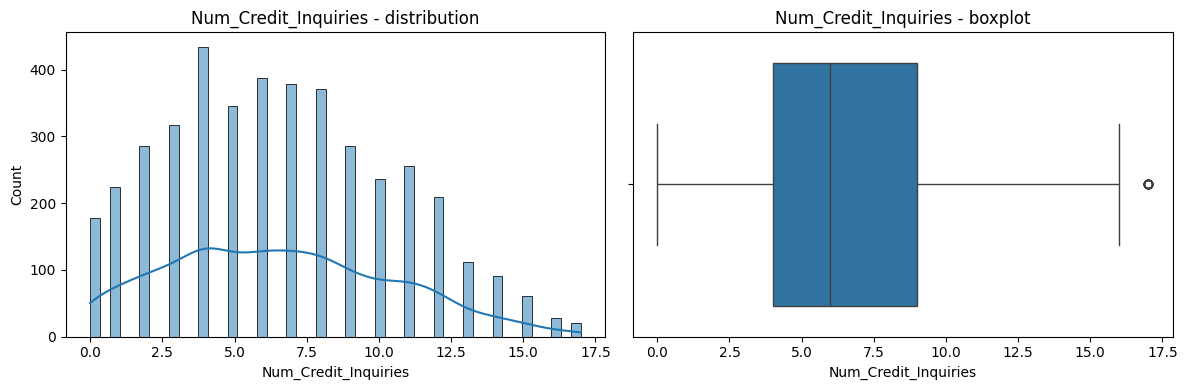

count    4217.000000
mean        6.597344
std         3.883084
min         0.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        17.000000
Name: Num_Credit_Inquiries, dtype: float64


In [587]:
credit_inquiries = (
  financials_cleaned_df
  .select("Num_Credit_Inquiries")
  .dropna()
  .toPandas()["Num_Credit_Inquiries"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_inquiries, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Num_Credit_Inquiries - distribution")
axes[0].set_xlabel("Num_Credit_Inquiries")

sns.boxplot(x=credit_inquiries, ax=axes[1])
axes[1].set_title("Num_Credit_Inquiries - boxplot")

plt.tight_layout()
plt.show()

print(credit_inquiries.describe())

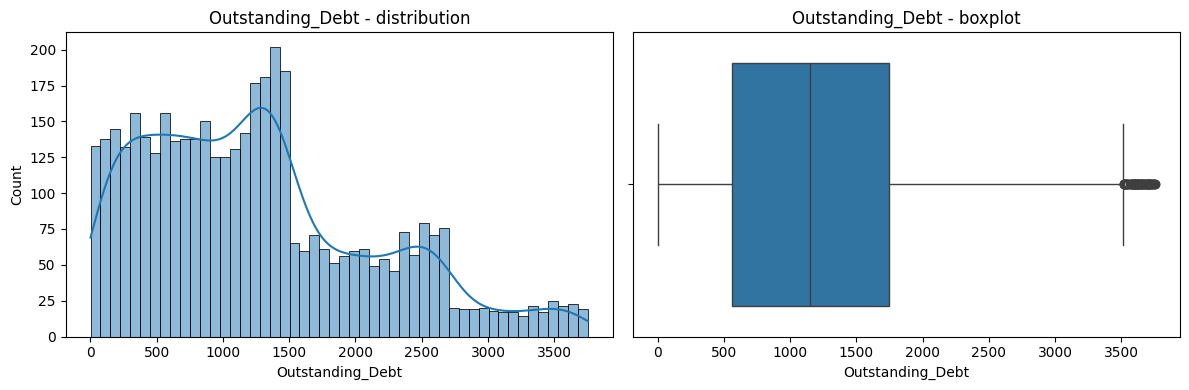

count    4217.000000
mean     1257.733032
std       870.591675
min         0.540000
25%       565.479980
50%      1153.000000
75%      1745.530029
max      3754.620117
Name: Outstanding_Debt, dtype: float64


In [588]:
out_debt = (
  financials_cleaned_df
  .select("Outstanding_Debt")
  .dropna()
  .toPandas()["Outstanding_Debt"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(out_debt, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Outstanding_Debt - distribution")
axes[0].set_xlabel("Outstanding_Debt")

sns.boxplot(x=out_debt, ax=axes[1])
axes[1].set_title("Outstanding_Debt - boxplot")

plt.tight_layout()
plt.show()

print(out_debt.describe())

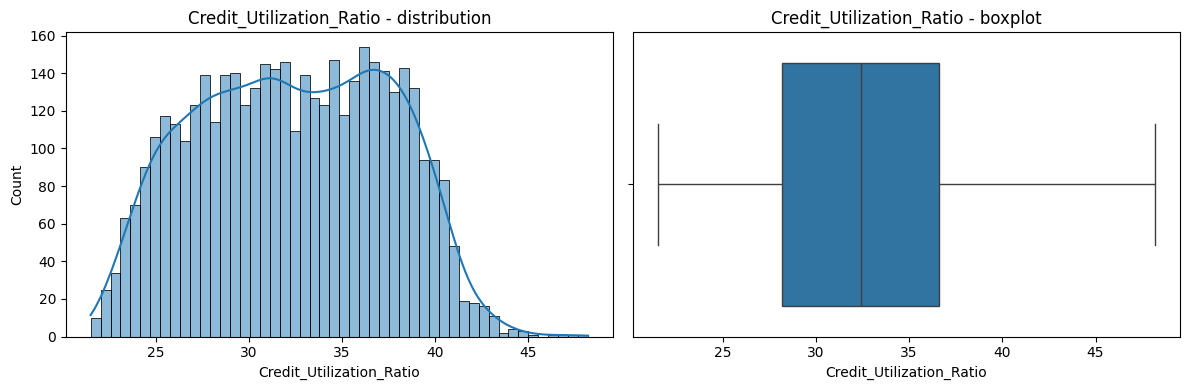

count    4217.000000
mean       32.355179
std         5.087967
min        21.502216
25%        28.152073
50%        32.404083
75%        36.595726
max        48.199825
Name: Credit_Utilization_Ratio, dtype: float64


In [589]:
credit_ratio = (
  financials_cleaned_df
  .select("Credit_Utilization_Ratio")
  .dropna()
  .toPandas()["Credit_Utilization_Ratio"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_ratio, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Credit_Utilization_Ratio - distribution")
axes[0].set_xlabel("Credit_Utilization_Ratio")

sns.boxplot(x=credit_ratio, ax=axes[1])
axes[1].set_title("Credit_Utilization_Ratio - boxplot")

plt.tight_layout()
plt.show()

print(credit_ratio.describe())

In [590]:
financials_cleaned_df.groupBy("Total_EMI_per_month").count().orderBy(F.desc("count")).show()

[Stage 1442:>                                                       (0 + 1) / 1]

+-------------------+-----+
|Total_EMI_per_month|count|
+-------------------+-----+
|          41.947273|    1|
|           89.91109|    1|
|          29.541637|    1|
|          125.39966|    1|
|          103.29709|    1|
|          146.70764|    1|
|          35.013702|    1|
|           74.06279|    1|
|          61.351936|    1|
|          152.13756|    1|
|          116.53075|    1|
|          111.51961|    1|
|          169.87616|    1|
|           48.78797|    1|
|           72.12381|    1|
|          111.22703|    1|
|            78.6704|    1|
|          123.06464|    1|
|           77.96876|    1|
|          47.332718|    1|
+-------------------+-----+
only showing top 20 rows


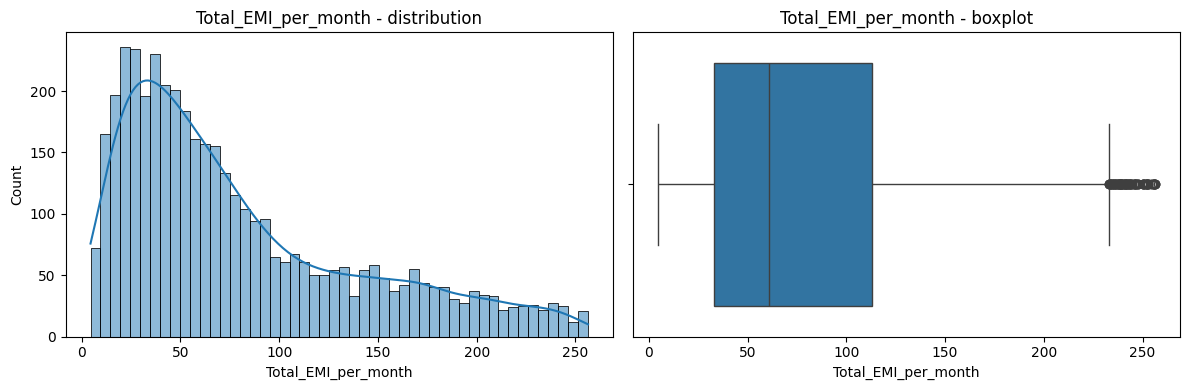

count    4217.000000
mean       80.377731
std        61.168388
min         4.462838
25%        33.013905
50%        60.787743
75%       112.966698
max       256.374603
Name: Total_EMI_per_month, dtype: float64


In [591]:
emi = (
  financials_cleaned_df
  .select("Total_EMI_per_month")
  .dropna()
  .toPandas()["Total_EMI_per_month"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(emi, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Total_EMI_per_month - distribution")
axes[0].set_xlabel("Total_EMI_per_month")

sns.boxplot(x=emi, ax=axes[1])
axes[1].set_title("Total_EMI_per_month - boxplot")

plt.tight_layout()
plt.show()

print(emi.describe())

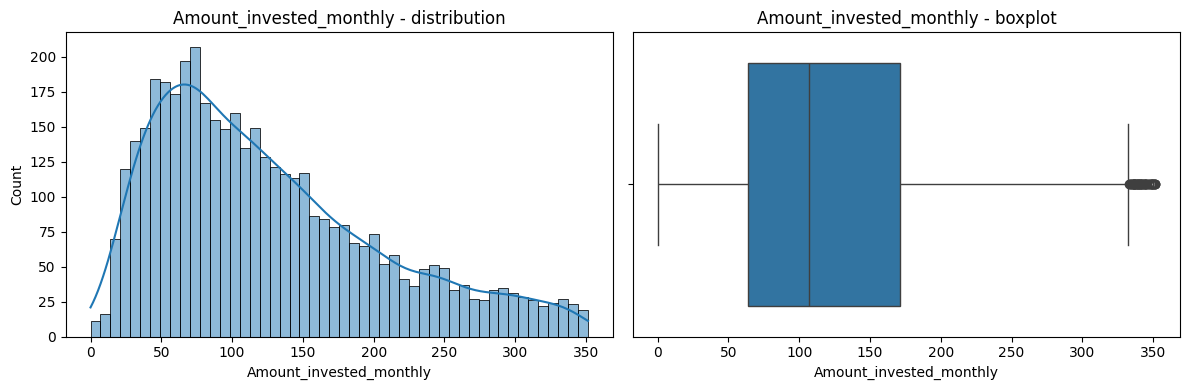

count    4217.000000
mean      125.700035
std        80.004616
min         0.000000
25%        63.616844
50%       107.076065
75%       171.249527
max       351.388885
Name: Amount_invested_monthly, dtype: float64


In [592]:
amt = (
  financials_cleaned_df
  .select("Amount_invested_monthly")
  .dropna()
  .toPandas()["Amount_invested_monthly"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(amt, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Amount_invested_monthly - distribution")
axes[0].set_xlabel("Amount_invested_monthly")

sns.boxplot(x=amt, ax=axes[1])
axes[1].set_title("Amount_invested_monthly - boxplot")

plt.tight_layout()
plt.show()

print(amt.describe())

In [593]:
financials_cleaned_df.groupBy("Monthly_Balance").count().orderBy(F.desc("count")).show()

[Stage 1447:>                                                       (0 + 1) / 1]

+---------------+-----+
|Monthly_Balance|count|
+---------------+-----+
|      312.99075|    2|
|      340.73236|    1|
|       565.7248|    1|
|      467.88367|    1|
|      308.32672|    1|
|      215.56615|    1|
|      415.19278|    1|
|      386.13602|    1|
|        288.729|    1|
|      243.87532|    1|
|      327.66632|    1|
|      578.19037|    1|
|      554.95123|    1|
|      273.67676|    1|
|      368.04718|    1|
|      443.16135|    1|
|       296.1725|    1|
|      249.12524|    1|
|      604.45746|    1|
|      253.27905|    1|
+---------------+-----+
only showing top 20 rows


### Sanity bound

In [594]:
# IQR = Q3 − Q1
# Tukey upper fence (1.5·IQR)

def tukey_upper_fence(df, column, k=1.5):
  q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.001)
  iqr = q3 - q1
  fence = q3 + k * iqr
  print(f"{column}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, upper_fence({k}·IQR)={fence:.2f}")
  return fence

In [595]:
cols_to_filter = [
  "Num_Bank_Accounts",
  "Num_Credit_Card",
  "Interest_Rate",
  "Num_of_Loan",
  "Delay_from_due_date",
  "Num_of_Delayed_Payment",
  "Changed_Credit_Limit",
  "Outstanding_Debt",
  "Num_Credit_Inquiries",
  "Total_EMI_per_month",
  "Amount_invested_monthly",
]

fences = {c: tukey_upper_fence(financials_cleaned_df, c) for c in cols_to_filter}

print("\nFilter ranges (Tukey 1.5·IQR upper fence):\n")
for c, upper in fences.items():
  print(f"  .filter(col(\"{c}\").between(0, {upper:.2f}))")

# apply the filters
for c, upper in fences.items():
  financials_cleaned_df = financials_cleaned_df.filter(col(c).between(0, upper))

print("\nrows after filtering:", financials_cleaned_df.count())

Num_Bank_Accounts: Q1=4.00, Q3=7.00, IQR=3.00, upper_fence(1.5·IQR)=11.50


Num_Credit_Card: Q1=4.00, Q3=7.00, IQR=3.00, upper_fence(1.5·IQR)=11.50


Interest_Rate: Q1=8.00, Q3=20.00, IQR=12.00, upper_fence(1.5·IQR)=38.00


Num_of_Loan: Q1=2.00, Q3=5.00, IQR=3.00, upper_fence(1.5·IQR)=9.50


Delay_from_due_date: Q1=10.00, Q3=26.00, IQR=16.00, upper_fence(1.5·IQR)=50.00


...

Num_Credit_Inquiries: Q1=4.00, Q3=9.00, IQR=5.00, upper_fence(1.5·IQR)=16.50


Total_EMI_per_month: Q1=32.87, Q3=112.59, IQR=79.72, upper_fence(1.5·IQR)=232.17


Amount_invested_monthly: Q1=63.61, Q3=170.94, IQR=107.32, upper_fence(1.5·IQR)=331.92

Filter ranges (Tukey 1.5·IQR upper fence):

  .filter(col("Num_Bank_Accounts").between(0, 11.50))
  .filter(col("Num_Credit_Card").between(0, 11.50))
  .filter(col("Interest_Rate").between(0, 38.00))
  .filter(col("Num_of_Loan").between(0, 9.50))
  .filter(col("Delay_from_due_date").between(0, 50.00))
  .filter(col("Num_of_Delayed_Payment").between(0, 31.50))
  .filter(col("Changed_Credit_Limit").between(0, 27.18))
  .filter(col("Outstanding_Debt").between(0, 3495.48))
  .filter(col("Num_Credit_Inquiries").between(0, 16.50))
  .filter(col("Total_EMI_per_month").between(0, 232.17))
  .filter(col("Amount_invested_monthly").between(0, 331.92))


[Stage 1483:>                                                       (0 + 1) / 1]


rows after filtering: 3911


In [596]:
# filter out outliers based on the visualisation and row count

financials_cleaned_df = (
    financials_cleaned_df
    
    .filter(col("Num_Bank_Accounts").between(0, 10))
    .filter(col("Num_Credit_Card").between(0, 10))
    .filter(col("Interest_Rate").between(0, 34))
    .filter(col("Num_of_Loan").between(0, 9))
    .filter(col("Delay_from_due_date").between(0, 55))
    .filter(col("Num_of_Delayed_Payment").between(0, 25))
    .filter(col("Changed_Credit_Limit").between(0, 30))
    .filter(col("Outstanding_Debt").between(0, 4500))
    .filter(col("Num_Credit_Inquiries").between(0, 18))
    .filter(col("Total_EMI_per_month").between(0, 370))
    .filter(col("Amount_invested_monthly").between(0, 420))
)


In [597]:
# saved the cleaned dataset
financials_cleaned_df.toPandas().to_csv("./data/features_financials_cleaned.csv", index=False)
print("Done")

Done
